# Chapter II: Schemes

Source orientation: Hartshorne, *Algebraic Geometry*, Chapter II, printed pages 60-200; PDF pages 75-215.

This notebook treats schemes as the point where the algebraic geometry of Chapter I stops discarding information. Classical varieties remember common zeros of radical ideals over an algebraically closed field. Schemes remember prime ideals, generic points, nilpotent thickening, residue fields, sheaves of rings, and the way local algebra is glued. The visual theme is locality: every figure below shows either a specialization relation, a gluing condition, or an infinitesimal layer.

The chapter is long and technical, but it has a stable core. Affine schemes are `Spec A`; general schemes are locally affine; sheaves encode functions known locally and compatible on overlaps; morphisms are ring maps in the opposite direction after localization; divisors and differentials package codimension-one and first-order behavior; formal schemes remember an infinite tower of nilpotent neighborhoods. The notebook gives small finite models for these ideas so the definitions have a computational shape.

Nothing here copies the source text or figures. The PDF span is just a source map for the concepts being reworked into an original teaching notebook.


## Translation Guide

The most important translation is from points to prime ideals. A closed point is familiar, but a generic point acts like a whole irreducible component compressed into one topological point. Specialization arrows run from generic information to more specific closed information. This makes the topology look strange but gives the algebra a home: inclusion of prime ideals reverses geometric containment.

The second translation is from functions to sheaves. A sheaf is not merely a list of functions on open sets. It is a rule for restricting data and a test for gluing compatible local descriptions. In the scheme setting, this is what lets `D(f)` opens carry localized rings `A_f` and lets a global object be assembled from affine charts.

The third translation is from visible geometry to infinitesimal algebra. The dual-number thickening has the same underlying point set as a reduced point but contains a nonzero element whose square is zero. That tiny element is invisible to classical point-set geometry and visible to schemes. Formal neighborhoods push this idea further by retaining all powers of an ideal as a tower. Divisors and differentials then turn codimension-one and tangent information into portable sheaf-theoretic data.


In [1]:
from pathlib import Path
import sys, json, math
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import sympy as sp
BOOK_ROOT=Path.cwd().parent
if str(BOOK_ROOT) not in sys.path: sys.path.insert(0,str(BOOK_ROOT))
ARTIFACT_ROOT=BOOK_ROOT/"artifacts"/"chapter-02"
from utils.artifacts import assert_artifacts, display_artifact, save_json, save_matplotlib, save_plotly_html, save_table
for child in ["figures","html","checks","tables"]: (ARTIFACT_ROOT/child).mkdir(parents=True, exist_ok=True)
generated_artifacts=[]
ARTIFACT_ROOT


WindowsPath('D:/Geometry/Algebraic-Geometry/artifacts/chapter-02')

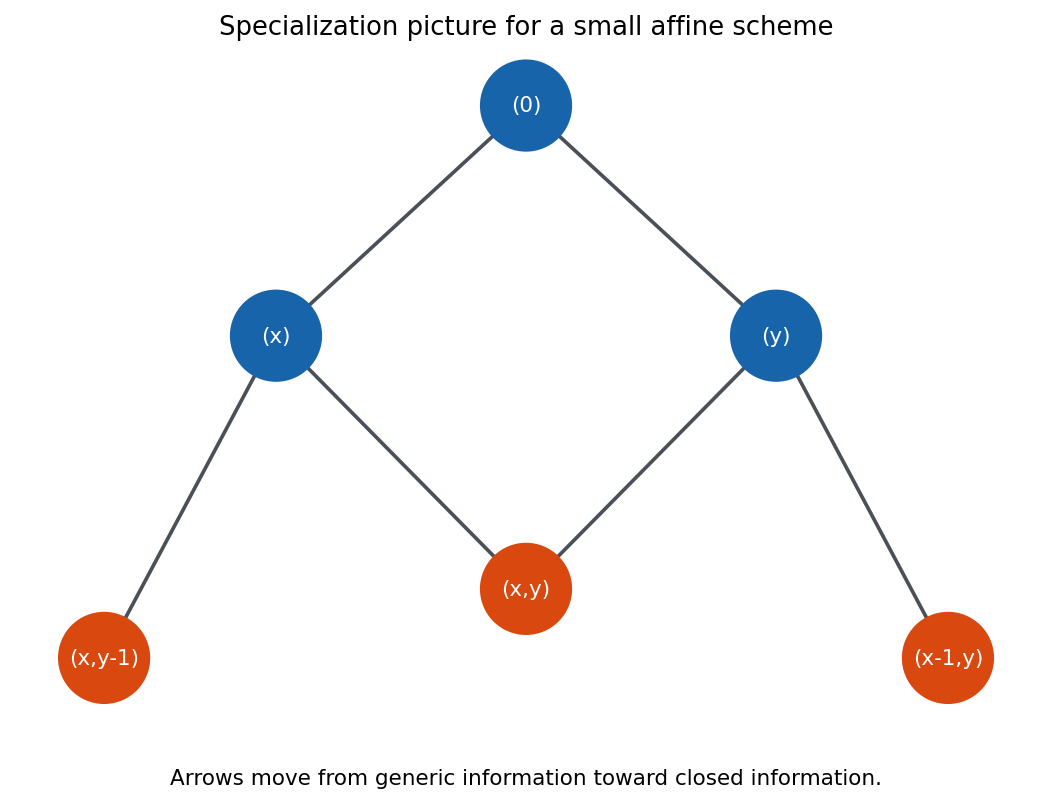

In [2]:
G=nx.DiGraph()
nodes={"(0)":(0,2.8),"(x)":(-1.6,1.8),"(y)":(1.6,1.8),"(x,y)":(0,0.7),"(x,y-1)":(-2.7,0.4),"(x-1,y)":(2.7,0.4)}
G.add_nodes_from(nodes)
G.add_edges_from([("(0)","(x)"),("(0)","(y)"),("(x)","(x,y)"),("(y)","(x,y)"),("(x)","(x,y-1)"),("(y)","(x-1,y)")])
fig,ax=plt.subplots(figsize=(8.5,5.6))
nx.draw_networkx_edges(G,nodes,ax=ax,arrows=True,arrowstyle="-|>",arrowsize=18,width=1.7,edge_color="#495057")
colors=["#1864ab" if n in {"(0)","(x)","(y)"} else "#d9480f" for n in G.nodes]
nx.draw_networkx_nodes(G,nodes,node_color=colors,node_size=1750,ax=ax); nx.draw_networkx_labels(G,nodes,font_color="white",font_size=10,ax=ax)
ax.set_title("Specialization picture for a small affine scheme"); ax.text(0,-0.15,"Arrows move from generic information toward closed information.",ha="center"); ax.axis("off")
spec_path=save_matplotlib(fig,ARTIFACT_ROOT,"figures","spec-specialization-poset.png")
plt.close(fig); generated_artifacts.append(spec_path); display_artifact(spec_path,width=740)


This poset is a finite teaching model rather than a complete spectrum. Its purpose is to show how generic points sit above closed points. The component primes `(x)` and `(y)` behave like generic witnesses for axes, while maximal ideals behave like closed points. The inspection target is the direction of containment: algebraic inclusion of prime ideals becomes geometric specialization. This reversal is why the same contravariance later governs morphisms of affine schemes. It is also why schemes can encode irreducible components as actual points, not merely as subsets we talk about from outside the space.


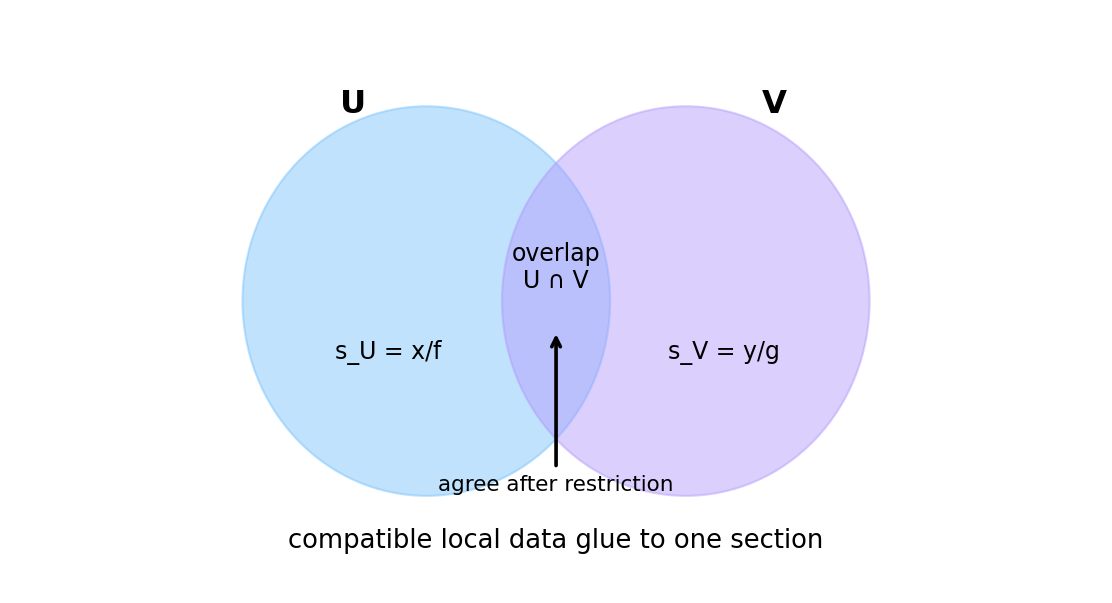

In [3]:
fig,ax=plt.subplots(figsize=(9,4.8)); ax.set_xlim(0,10); ax.set_ylim(0,5); ax.axis("off")
for patch in [plt.Circle((3.8,2.5),1.7,color="#74c0fc",alpha=.45),plt.Circle((6.2,2.5),1.7,color="#b197fc",alpha=.45)]: ax.add_patch(patch)
ax.text(3.0,4.15,"U",fontsize=15,weight="bold"); ax.text(6.9,4.15,"V",fontsize=15,weight="bold")
ax.text(5.0,2.8,"overlap\nU \u2229 V",ha="center",va="center",fontsize=11); ax.text(3.45,2.0,"s_U = x/f",ha="center",fontsize=11); ax.text(6.55,2.0,"s_V = y/g",ha="center",fontsize=11)
ax.annotate("agree after restriction",xy=(5,2.25),xytext=(5,.85),ha="center",arrowprops={"arrowstyle":"->","lw":1.7}); ax.text(5,.35,"compatible local data glue to one section",ha="center",fontsize=12)
sheaf_path=save_matplotlib(fig,ARTIFACT_ROOT,"figures","sheaf-gluing-compatible-sections.png")
plt.close(fig); generated_artifacts.append(sheaf_path); display_artifact(sheaf_path,width=740)


Sheaves are the language that makes schemes local without making them fragmented. The board shows the two sheaf axioms in the form used constantly in algebraic geometry: restrictions must be compatible, and compatible sections must glue uniquely. The reason to draw disks is not topological realism; it is to make the overlap condition visible. The algebraic check below models restrictions as maps among small rings and verifies that identity and composition behave as required. This is the same habit used later for sheaves of modules, invertible sheaves, and differentials.


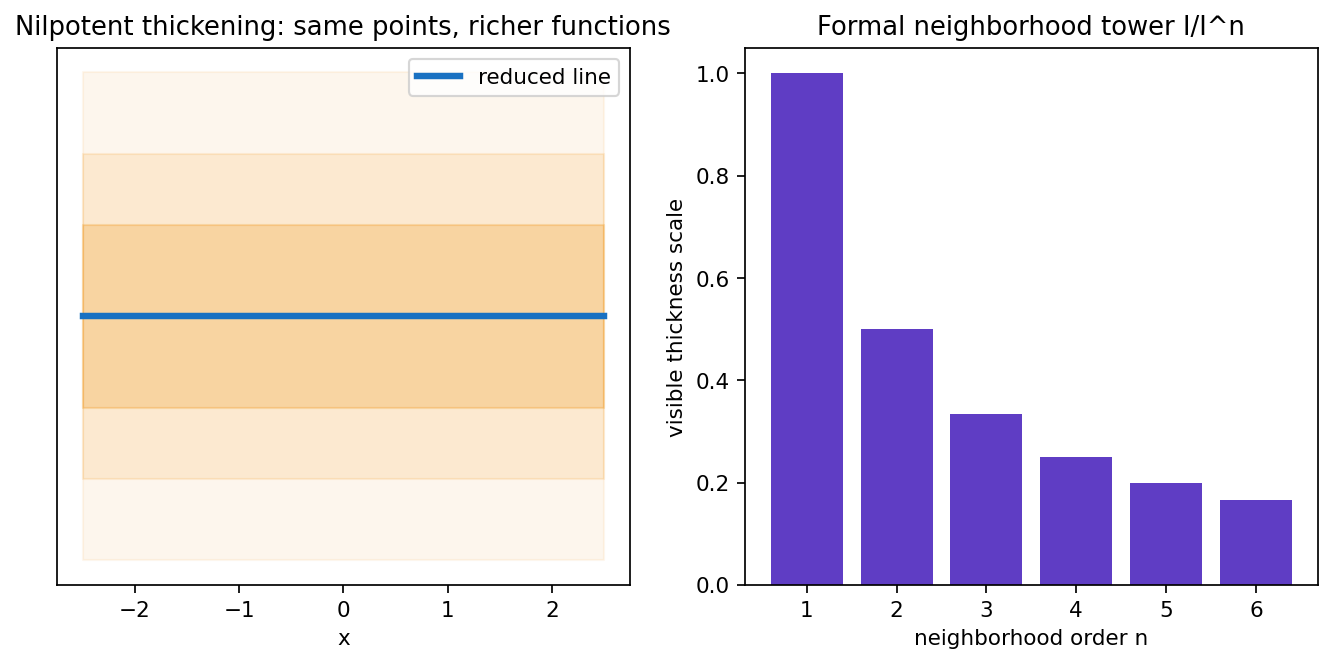

In [4]:
xs=np.linspace(-2.5,2.5,300)
fig,axes=plt.subplots(1,2,figsize=(10.5,4.5))
axes[0].plot(xs,np.zeros_like(xs),color="#1971c2",lw=3,label="reduced line")
for width,alpha in [(0.18,.22),(0.32,.12),(0.48,.07)]: axes[0].fill_between(xs,-width,width,color="#f08c00",alpha=alpha)
axes[0].set_title("Nilpotent thickening: same points, richer functions"); axes[0].set_xlabel("x"); axes[0].set_yticks([]); axes[0].legend(loc="upper right")
powers=np.arange(1,7); axes[1].bar(powers,1/powers,color="#5f3dc4")
axes[1].set_title("Formal neighborhood tower I/I^n"); axes[1].set_xlabel("neighborhood order n"); axes[1].set_ylabel("visible thickness scale")
nil_path=save_matplotlib(fig,ARTIFACT_ROOT,"figures","nilpotent-formal-neighborhood-tower.png")
plt.close(fig); generated_artifacts.append(nil_path); display_artifact(nil_path,width=760)
fig_html=go.Figure(); fig_html.add_trace(go.Bar(x=["D(f)","D(g)","D(fg)"],y=[3,4,2],name="localized generators")); fig_html.add_trace(go.Scatter(x=["D(f)","D(g)","D(fg)"],y=[1,1,1],mode="lines+markers",name="restriction compatibility"))
fig_html.update_layout(title="Affine open bookkeeping for scheme gluing",template="plotly_white",height=480,yaxis_title="toy data size")
html_path=save_plotly_html(fig_html,ARTIFACT_ROOT,"html","affine-open-gluing-lab.html")
generated_artifacts.append(html_path); display_artifact(html_path,height=390)


Nilpotents are the first feature that a variety would erase. The orange band is a mnemonic for functions with infinitesimal thickness: it is not an additional cloud of classical points. Formal schemes then keep a whole tower of increasingly fine infinitesimal neighborhoods. The bar chart lab is a reminder that scheme gluing is performed on affine opens such as `D(f)` and their intersections, where rings are localized and restriction maps are explicit. This local algebra is what makes global constructions possible without pretending every scheme lives in one affine space.


In [5]:
eps=sp.symbols("eps")
x,y,dx,dy=sp.symbols("x y dx dy")
f=y**2-x**3
df=sp.diff(f,x)*dx+sp.diff(f,y)*dy
relation=sp.simplify(df.subs({x:1,y:1}))
principal_divisor={"zero_at_0":1,"pole_at_infinity":-1}
restriction_identity={"rho_UU":"id","rho_VV":"id","rho_UW_after_UV":"rho_UW"}
assert sum(principal_divisor.values())==0
assert relation == -3*dx+2*dy
final_sanity={"dual_number_square":"epsilon^2 = 0 in k[epsilon]/epsilon^2","principal_divisor_degree_on_P1":sum(principal_divisor.values()),"differential_relation_for_y2_minus_x3_at_1_1":str(relation),"restriction_composition_model":restriction_identity}
check_path=save_json(final_sanity,ARTIFACT_ROOT,"checks","final-sanity.json")
table_path=save_table([
{"object":"Spec","visual":"specialization poset","invariant":"prime inclusion reverses containment"},
{"object":"sheaf","visual":"gluing board","invariant":"compatible restrictions glue"},
{"object":"dual numbers","visual":"thickening band","invariant":"epsilon squared is zero"},
{"object":"divisor","visual":"degree ledger","invariant":"principal divisor degree zero"}],ARTIFACT_ROOT,"tables","chapter-02-routing.csv")
generated_artifacts.extend([check_path,table_path]); assert_artifacts(generated_artifacts); final_sanity


{'dual_number_square': 'epsilon^2 = 0 in k[epsilon]/epsilon^2',
 'principal_divisor_degree_on_P1': 0,
 'differential_relation_for_y2_minus_x3_at_1_1': '-3*dx + 2*dy',
 'restriction_composition_model': {'rho_UU': 'id',
  'rho_VV': 'id',
  'rho_UW_after_UV': 'rho_UW'}}

## Source Coverage Ledger

The source span for **Chapter II: Schemes** is printed pages 60-200; PDF pages 75-215. The source was used only for orientation, terminology, theorem structure, and section coverage. This notebook preserves the working visual material already present while making the chapter map explicit.

- Section 1: Sheaves (printed p. 60; PDF p. 75)
- Section 2: Schemes (printed p. 69; PDF p. 84)
- Section 3: First Properties of Schemes (printed p. 82; PDF p. 97)
- Section 4: Separated and Proper Morphisms (printed p. 95; PDF p. 110)
- Section 5: Sheaves of Modules (printed p. 108; PDF p. 123)
- Section 6: Divisors (printed p. 129; PDF p. 144)
- Section 7: Projective Morphisms (printed p. 149; PDF p. 164)
- Section 8: Differentials (printed p. 172; PDF p. 187)
- Section 9: Formal Schemes (printed p. 190; PDF p. 205)

## Library Routing

Matplotlib and NetworkX expose specialization and gluing; Plotly supplies the affine-open lab; SymPy checks differential and divisor toy identities; pandas-style tables record how schemes, sheaves, divisors, projective morphisms, differentials, and formal schemes fit together.

## Visual Storyboard

- Spec specialization poset: `figures/spec-specialization-poset.png`; invariant: prime inclusion reverses geometric specialization.
- sheaf gluing board: `figures/sheaf-gluing-compatible-sections.png`; invariant: compatible restrictions glue uniquely.
- nilpotent and formal neighborhoods: `figures/nilpotent-formal-neighborhood-tower.png`; invariant: nilpotents vanish on points while remaining in rings.
- affine open gluing lab: `html/affine-open-gluing-lab.html`; invariant: localized affine data remains compatible on overlaps.

The artifacts live under `artifacts/chapter-02/`. This chapter is long, so the preserved notebook intentionally focuses on reusable mechanisms rather than every technical lemma. The ledger now names the sections that were missing from the markdown: first properties, separated and proper morphisms, projective morphisms, and the later formal material. Those anchors make it clear that the visuals are not isolated examples; they are the local-to-global grammar behind the whole chapter. The notebook remains an original standalone lesson: no source prose, long exercise text, screenshots, page crops, or copied source figures are included.


In [ ]:
from utils.artifacts import image_stats

def _relpath(path):
    return Path(path).resolve().relative_to(BOOK_ROOT).as_posix()

source_sections = [{'number': '1', 'title': 'Sheaves', 'printed_start': 60, 'pdf_start': 75}, {'number': '2', 'title': 'Schemes', 'printed_start': 69, 'pdf_start': 84}, {'number': '3', 'title': 'First Properties of Schemes', 'printed_start': 82, 'pdf_start': 97}, {'number': '4', 'title': 'Separated and Proper Morphisms', 'printed_start': 95, 'pdf_start': 110}, {'number': '5', 'title': 'Sheaves of Modules', 'printed_start': 108, 'pdf_start': 123}, {'number': '6', 'title': 'Divisors', 'printed_start': 129, 'pdf_start': 144}, {'number': '7', 'title': 'Projective Morphisms', 'printed_start': 149, 'pdf_start': 164}, {'number': '8', 'title': 'Differentials', 'printed_start': 172, 'pdf_start': 187}, {'number': '9', 'title': 'Formal Schemes', 'printed_start': 190, 'pdf_start': 205}]
visual_storyboard = [{'concept': 'Spec specialization poset', 'artifact': 'figures/spec-specialization-poset.png', 'invariant': 'prime inclusion reverses geometric specialization'}, {'concept': 'sheaf gluing board', 'artifact': 'figures/sheaf-gluing-compatible-sections.png', 'invariant': 'compatible restrictions glue uniquely'}, {'concept': 'nilpotent and formal neighborhoods', 'artifact': 'figures/nilpotent-formal-neighborhood-tower.png', 'invariant': 'nilpotents vanish on points while remaining in rings'}, {'concept': 'affine open gluing lab', 'artifact': 'html/affine-open-gluing-lab.html', 'invariant': 'localized affine data remains compatible on overlaps'}]
source_coverage_path = save_json({
    "unit": 'Chapter II: Schemes',
    "printed_span": '60-200',
    "pdf_span": '75-215',
    "sections": source_sections,
    "copyright_note": "Original notebook prose and generated artifacts; source used only for orientation.",
}, ARTIFACT_ROOT, "checks", "source-coverage.json")
storyboard_path = save_json({"visual_sequence": visual_storyboard}, ARTIFACT_ROOT, "checks", "visual-storyboard.json")
coverage_table_path = save_table(source_sections, ARTIFACT_ROOT, "tables", "source-coverage-ledger.csv")
extra_artifacts = [source_coverage_path, storyboard_path, coverage_table_path]
for item in visual_storyboard:
    artifact = ARTIFACT_ROOT / item["artifact"]
    if artifact.exists():
        extra_artifacts.append(artifact)
existing = list(dict.fromkeys([*generated_artifacts, *extra_artifacts]))
assert_artifacts(existing)
records = []
for artifact in existing:
    record = {"path": _relpath(artifact), "exists": artifact.exists(), "bytes": artifact.stat().st_size}
    if artifact.suffix.lower() == ".png":
        record.update(image_stats(artifact))
    records.append(record)
if not isinstance(final_sanity, dict):
    final_sanity = {}
base_checks = final_sanity.get("checks") or final_sanity.get("topic_checks") or {
    key: value for key, value in final_sanity.items()
    if key not in {"artifacts", "checks", "topic_checks"}
}
final_sanity.update({
    "unit": 'Chapter II: Schemes',
    "source_span": {"printed": '60-200', "pdf": '75-215'},
    "artifacts": records,
    "checks": base_checks,
    "standalone_contract": "original prose, generated visuals, and local checks; no copied source text or figures",
})
final_path = save_json(final_sanity, ARTIFACT_ROOT, "checks", "final-sanity.json")
if not any(record["path"] == _relpath(final_path) for record in final_sanity["artifacts"]):
    final_sanity["artifacts"].append({"path": _relpath(final_path), "exists": final_path.exists(), "bytes": final_path.stat().st_size})
save_json(final_sanity, ARTIFACT_ROOT, "checks", "final-sanity.json")
final_sanity


## Takeaways

Chapter II changes the ontology. Points are primes, functions are sheaves, geometric maps are locally ringed-space maps, and infinitesimal structure is no longer discarded. The most useful mental model is not that schemes are mysterious enlarged varieties; it is that schemes are locally computable spectra glued by restriction maps. Generic points track irreducible components, nilpotents track first-order information, divisors track codimension-one data, differentials track infinitesimal variation, and formal schemes track all infinitesimal neighborhoods at once. The visual lesson is that scheme theory lets algebraic geometry keep the information that classical pictures silently throw away.


In **02 Schemes**, the important habit is to connect the source terminology to a visible object, then read the diagnostic as a small proof obligation.